# 캘리포니아 집 값 데이터

> 집 값(median_house_value)을 예측하세요. => 회귀문제다 !

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# plt.rc('font', family='D2Coding')
# plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['font.family'] = 'Malgun Gothic'

In [59]:
housing = pd.read_csv('data/housing.csv')

In [ ]:
print("\n데이터 정보:")
print(housing.info())
print("\n데이터 통계:")
print(housing.describe())


데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None

데이터 통계:
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.00

In [61]:
print("\n결측치:")
print(housing.isnull().sum())


결측치:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


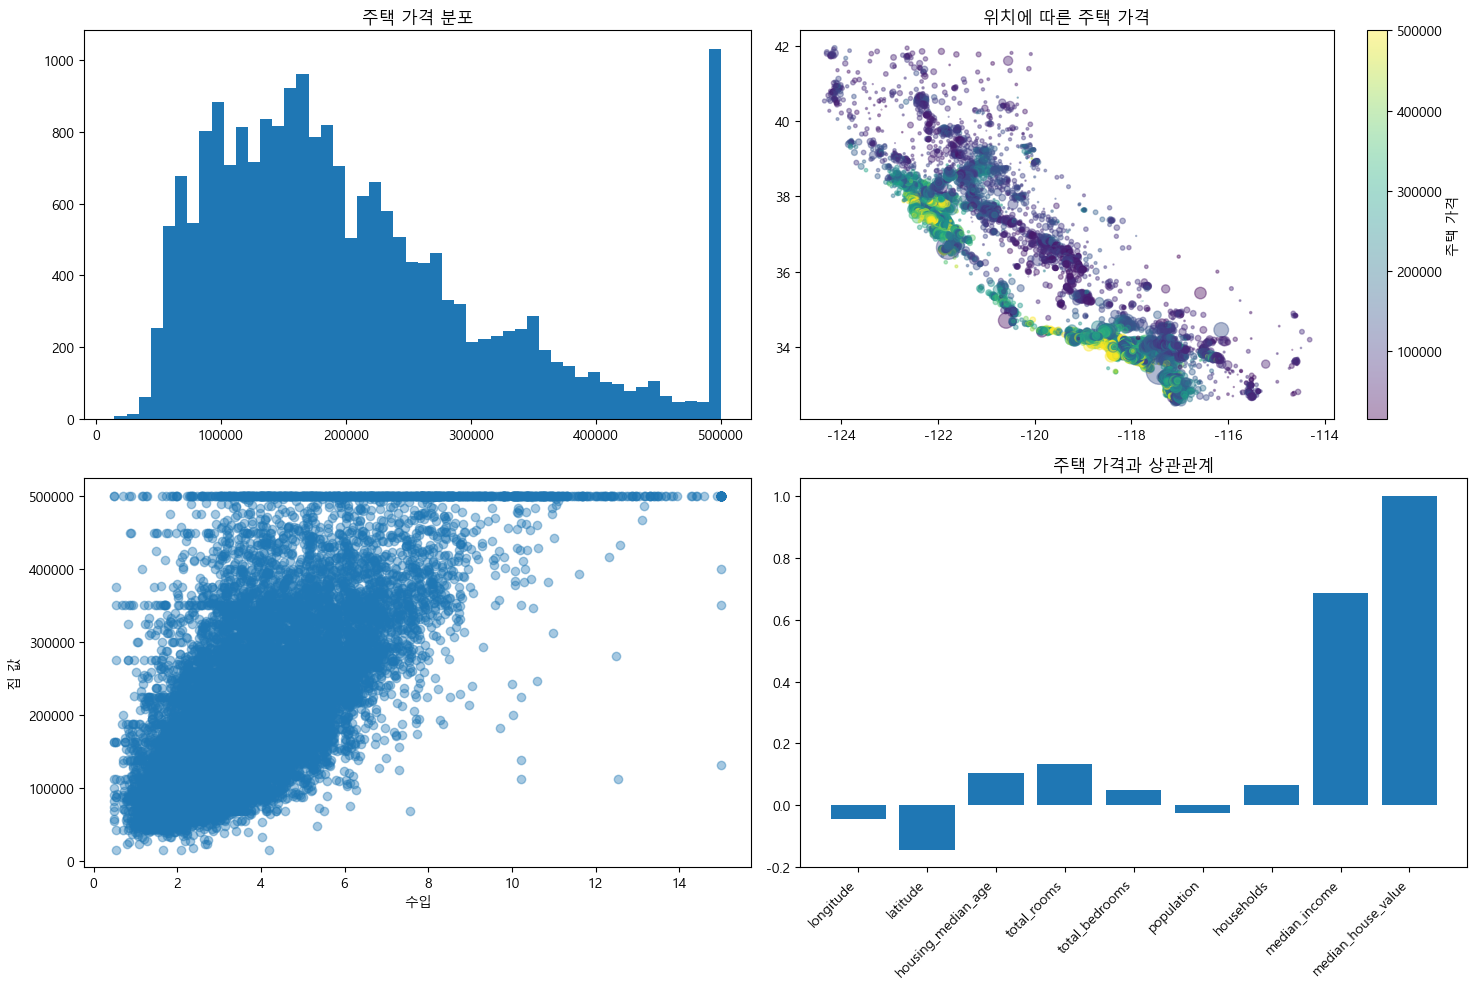

In [62]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
plt.hist(housing["median_house_value"], bins=50)
plt.title("주택 가격 분포")
plt.subplot(2,2,2)
plt.scatter(housing["longitude"], housing["latitude"], alpha=0.4, s=housing["population"]/100, c=housing["median_house_value"], cmap='viridis')
plt.colorbar(label="주택 가격")
plt.title("위치에 따른 주택 가격")
plt.subplot(2,2,3)
plt.scatter(housing["median_income"], housing["median_house_value"], alpha=0.4)
plt.xlabel("수입")
plt.ylabel("집 값")

corr = housing.corr(numeric_only=True)
plt.subplot(2,2,4)
plt.bar(corr["median_house_value"].index, corr["median_house_value"].values)
plt.title("주택 가격과 상관관계")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

In [63]:
X = housing.drop("median_house_value", axis=1) # 답안 뺸 거
y = housing["median_house_value"]

In [64]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [65]:
numerical_feat = X.select_dtypes(include=["int64", "float64"]).columns # "float64"으로 바꾸는 게 좋음
categorical_feat = ["ocean_proximity"]

In [66]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [67]:
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())])
numerical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [68]:
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown="ignore")) # 원핫 매개변수 신경쓰기
])
categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [ ]:
from sklearn.compose import ColumnTransformer # column을 수정하는 것
preprocessor = ColumnTransformer(transformers=[('num', numerical_transformer, numerical_feat),
                                ('cat', categorical_transformer, categorical_feat)])
preprocessor # 이 형태로 실행

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['ocean_proximity'])])

In [70]:
from sklearn.linear_model import LinearRegression
linear_model = Pipeline(
    [('preprocessor', preprocessor),
    ('regressor', LinearRegression())]
)
linear_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['ocean_proximity'])])),
                ('regressor', LinearRegression())])

In [ ]:
linear_model.fit(X_train, y_train) # fit은 전처리가 이미 끝난 X_train 데이터를 넣는 것임 (X_train : X 전처리한 것) 
linear_predictions = linear_model.predict(X_test)
linear_predictions

array([ 54811.88242313, 123864.33890936, 252845.43705076, ...,
       140614.11326652, 243327.82857325, 350156.23528829])

파이프라인 사용의 기준은 뭔가요?

> 인자(매개변수)가 동일해야 함

In [73]:
from sklearn.metrics import mean_squared_error, r2_score
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_mae = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)
print(f'{linear_mse}, {linear_mae}, {linear_r2}') # 결과 해석할 줄 알아야 함
# r2 : 0~1 사이로 나옴. 1에 가까울 수록 좋음. 데이터가 양질의 데이터라는 의미. 저 모델은 63%(설명력)가 발현된 것
# mse : 에러에 대한 평균값이니 낮을 수록 좋음
# mae : mse에 루트한 값. 0으로 다가갈 수록 좋음. 예측값보다 평균적으로 7만불 틀리다(위로든 아래로든)
# 비교대상군의 모델이 없으면 잘 된건지 모름

4796735617.124312, 69258.4696418013, 0.6374947108633109


In [74]:
# 랜덤포레스트
from sklearn.ensemble import RandomForestRegressor
forest_model = Pipeline(
    [('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor())]
)
forest_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['ocean_proximity'])])),
                ('regressor', RandomForestRegressor())])

- svm은 minmax쓰는 게 중론
- 파이프라인하기 전에 쭉 한 번 써서 파악해야 함

In [75]:
forest_model.fit(X_train, y_train) # fit은 전처리가 이미 끝난 X_train 데이터를 넣는 것임 (X_train : X 전처리한 것) 
forest_predictions = forest_model.predict(X_test)
forest_predictions

array([ 53154.  ,  70162.  , 461123.48, ..., 118323.  , 266518.  ,
       432866.36])

In [77]:
from sklearn.metrics import mean_squared_error, r2_score
forest_mse = mean_squared_error(y_test, forest_predictions)
forest_mae = np.sqrt(forest_mse)
forest_r2 = r2_score(y_test, forest_predictions)
print(f'{forest_mse}, {forest_mae}, {forest_r2}') 

2415181253.625945, 49144.49362467727, 0.8174767073804112


In [ ]:
from sklearn.model_selection import cross_val_score 
# 값이 작을 수록 좋은 것들은 cv 쓸 때 조심해야 함(하이퍼파라미터 튜닝 때문에 씀)
linear_scores = cross_val_score(linear_model, X, y, cv=5, scoring="neg_mean_squared_error") # neg_mean_squared_error : 반환되는 수치값이 음수 값이다
linear_rmse_scores = np.sqrt(-linear_scores) # -linear_scores : neg_mean_squared_error 이걸로 모든 값이 음수가 되었으니 (-) 붙이는 거임
print(f"{linear_scores}, {linear_scores.mean()}, {linear_rmse_scores.std()}")

[-5.40218314e+09 -5.72458107e+09 -5.75765496e+09 -5.94197800e+09
 -4.42270855e+09], -5449821144.21343, 3791.4279887813996


- RMSE는 이상치에 민감함
- RMSE는 실제 오차와 거의 유사 (대신 오차의 방향(과대/과소)은 알 수 없음)
- 오차를 제곱하기 때문에 RMSE값이 만약 커지면 오차를 제곱했어서 엄청 도드라지게 커짐
- cv, k-겹을 돌리면 이상치가 들어갈 수 있으니 RMSE 같이 쓴다고 생각해라

In [113]:
forest_scores = cross_val_score(forest_model, X, y, cv=5, scoring="neg_mean_squared_error")
forest_rmse_scores = np.sqrt(-forest_scores)
print(f"{forest_scores}, {forest_rmse_scores.mean()}, {forest_rmse_scores.std()}")

[-6.75601356e+09 -4.65287634e+09 -4.26155621e+09 -9.26018305e+09
 -5.14747692e+09], 76732.66569938304, 11301.293356188444


In [114]:
X_train_prepared = preprocessor.fit_transform(X_train)

In [115]:
forest = RandomForestRegressor()
forest.fit(X_train_prepared, y_train)

RandomForestRegressor()

In [116]:
one = preprocessor.named_transformers_['cat'].named_steps['onehot'] # 'cat' 안에 'onehot'을 가져와달라
cat_feat_names = one.get_feature_names_out(['ocean_proximity'])
feat_names = list(numerical_feat) + list(cat_feat_names)
feat_names

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'ocean_proximity_<1H OCEAN',
 'ocean_proximity_INLAND',
 'ocean_proximity_ISLAND',
 'ocean_proximity_NEAR BAY',
 'ocean_proximity_NEAR OCEAN']

In [117]:
imp = forest.feature_importances_
idx = np.argsort(imp)[::-1]
for i in range(len(imp)):
    if i < len(feat_names):
        print(f'{feat_names[i]}: {imp[idx[i]]}')

longitude: 0.48782458563642356
latitude: 0.1429682085565095
housing_median_age: 0.10538127910168604
total_rooms: 0.10090229456812398
total_bedrooms: 0.05180758067880989
population: 0.032754902710711076
households: 0.024811480414791184
median_income: 0.023811671615857347
ocean_proximity_<1H OCEAN: 0.018101035431235854
ocean_proximity_INLAND: 0.006918748386363904
ocean_proximity_ISLAND: 0.0035375623479906933
ocean_proximity_NEAR BAY: 0.0007795644082961514
ocean_proximity_NEAR OCEAN: 0.00040108614320085866


In [118]:
import joblib
joblib.dump(forest_model, 'housing_v1.pkl')

['housing_v1.pkl']

- 배포(aws?)는 해보셨을까요

In [119]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [120]:
housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [121]:
def predict_housing_v1(longitude, latitude, housing_median_age, total_rooms,
    total_bedrooms, population, households, median_income, ocean_proximity):
    # 1. 사용자 입력
    # 2. 모델 불러오기
    # 3. 모델에 해당 데이터 입력
    # 4. 결과를 출력
    input_data = pd.DataFrame({
        'longitude':[longitude], 'latitude':[latitude], 'housing_median_age':[housing_median_age], 'total_rooms':[total_rooms],
        'total_bedrooms':[total_bedrooms], 'population':[population], 'households':[households], 'median_income':[median_income], 'ocean_proximity':[ocean_proximity],
    })

    model = joblib.load("housing_V1.pkl")

    return model.predict(input_data)[0]

In [122]:
test_sample = X_test.iloc[0].copy()
actual_price = y_test.iloc[0]
predicted_price = predict_housing_v1(
    test_sample['longitude'], test_sample['latitude'], test_sample['housing_median_age'], test_sample['total_rooms'],
    test_sample['total_bedrooms'], test_sample['population'], test_sample['households'], test_sample['median_income'], test_sample['ocean_proximity']
)
predicted_price

np.float64(53154.0)